In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [2]:

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()


x_train = x_train / 255.0
x_test = x_test / 255.0

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training shape: (50000, 32, 32, 3)
Testing shape: (10000, 32, 32, 3)


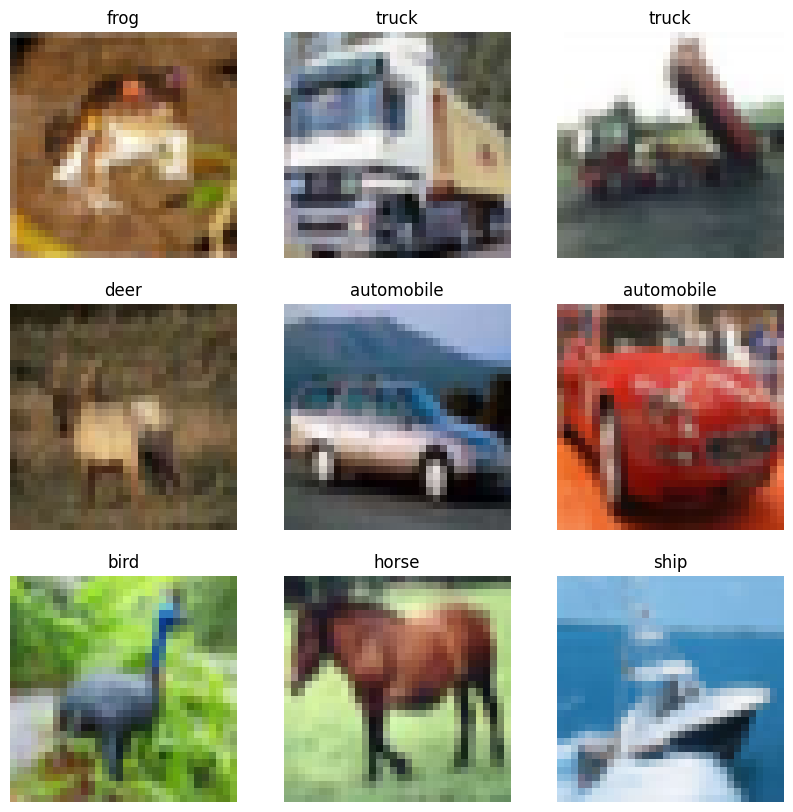

In [3]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [4]:
def create_model(num_conv_layers=2, learning_rate=0.001):

    model = models.Sequential()


    model.add(layers.Conv2D(32, (3,3), activation='relu',
                            input_shape=(32,32,3)))
    model.add(layers.MaxPooling2D((2,2)))


    for i in range(num_conv_layers - 1):
        model.add(layers.Conv2D(64, (3,3), activation='relu'))
        model.add(layers.MaxPooling2D((2,2)))


    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))


    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [5]:
learning_rates = [0.1, 0.01, 0.001]

lr_results = {}

for lr in learning_rates:

    print(f"\nTraining with Learning Rate = {lr}")

    model = create_model(num_conv_layers=2,
                         learning_rate=lr)

    history = model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=64,
        validation_data=(x_test, y_test),
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test)

    lr_results[lr] = test_acc

print("\nLearning Rate Results:")
print(lr_results)


Training with Learning Rate = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.0981 - loss: 6.3365 - val_accuracy: 0.1000 - val_loss: 2.3079
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1010 - loss: 2.3104 - val_accuracy: 0.1000 - val_loss: 2.3108
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.0980 - loss: 2.3113 - val_accuracy: 0.1000 - val_loss: 2.3164
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1030 - loss: 2.3106 - val_accuracy: 0.1000 - val_loss: 2.3067
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1012 - loss: 2.3105 - val_accuracy: 0.1000 - val_loss: 2.3060
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1000 - loss: 2.3060

Training with Learning Rate = 0.01
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.1005 - loss: 2.3055 - val_accuracy: 0.1000 - val_loss: 2.3031
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0978 - loss: 2.3037 - val_accuracy: 0.1000 - val_loss: 2.3034

In [6]:
batch_sizes = [32, 64, 128]

batch_results = {}

for batch in batch_sizes:

    print(f"\nTraining with Batch Size = {batch}")

    model = create_model(num_conv_layers=2,
                         learning_rate=0.001)

    history = model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=batch,
        validation_data=(x_test, y_test),
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test)

    batch_results[batch] = test_acc

print("\nBatch Size Results:")
print(batch_results)


Training with Batch Size = 32
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4868 - loss: 1.4317 - val_accuracy: 0.5996 - val_loss: 1.1484
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6215 - loss: 1.0814 - val_accuracy: 0.6512 - val_loss: 1.0088
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6674 - loss: 0.9567 - val_accuracy: 0.6641 - val_loss: 0.9838
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6988 - loss: 0.8666 - val_accuracy: 0.6740 - val_loss: 0.9555
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7256 - loss: 0.7907 - val_accuracy: 0.6967 - val_loss: 0.8928
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6967 - loss: 0.8928

Training with Batch Size = 64
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4429 - loss: 1.5439 - val_accuracy: 0.5467 - val_loss: 1.2720
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5810 - loss: 1.1914 - val

In [7]:
conv_layers = [1, 2, 3]

conv_results = {}

for conv in conv_layers:

    print(f"\nTraining with {conv} Conv Layers")

    model = create_model(num_conv_layers=conv,
                         learning_rate=0.001)

    history = model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=64,
        validation_data=(x_test, y_test),
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test)

    conv_results[conv] = test_acc

print("\nConvolution Layer Results:")
print(conv_results)


Training with 1 Conv Layers
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4613 - loss: 1.5131 - val_accuracy: 0.5260 - val_loss: 1.3236
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5759 - loss: 1.2119 - val_accuracy: 0.5725 - val_loss: 1.1971
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6132 - loss: 1.1066 - val_accuracy: 0.6103 - val_loss: 1.1139
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6407 - loss: 1.0328 - val_accuracy: 0.6222 - val_loss: 1.0905
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6633 - loss: 0.9647 - val_accuracy: 0.6152 - val_loss: 1.0932
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6152 - loss: 1.0932

Training with 2 Conv Layers
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4400 - loss: 1.5583 - val_accuracy: 0.5271 - val_loss: 1.3165
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5742 - loss: 1.2070 - val_accuracy: 0.58

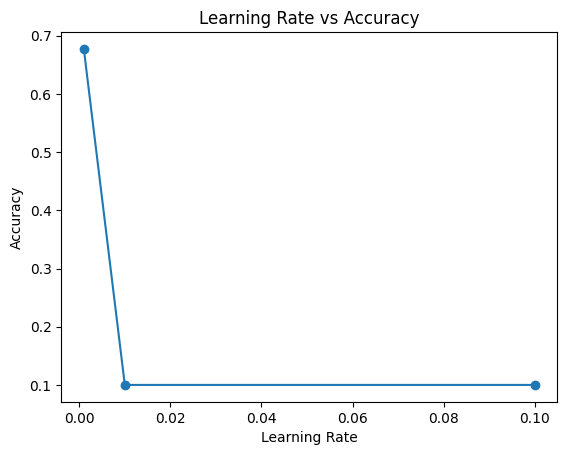

In [8]:
plt.plot(list(lr_results.keys()),
         list(lr_results.values()),
         marker='o')

plt.title("Learning Rate vs Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.show()

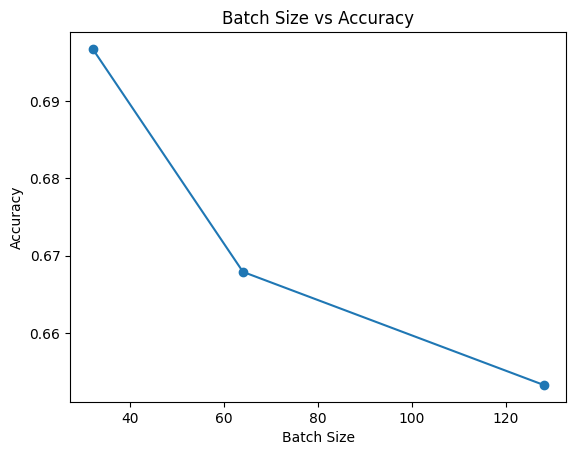

In [9]:
plt.plot(list(batch_results.keys()),
         list(batch_results.values()),
         marker='o')

plt.title("Batch Size vs Accuracy")
plt.xlabel("Batch Size")
plt.ylabel("Accuracy")
plt.show()

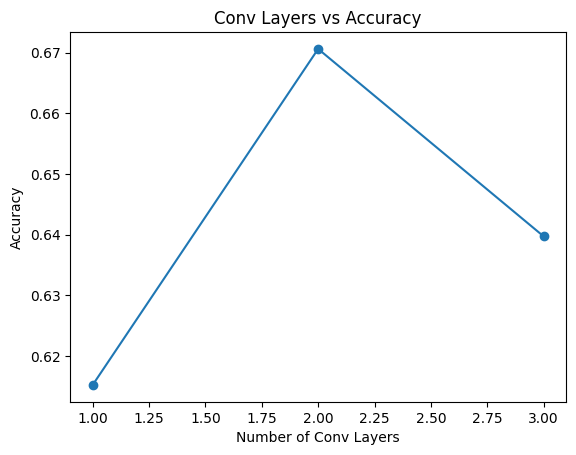

In [10]:
plt.plot(list(conv_results.keys()),
         list(conv_results.values()),
         marker='o')

plt.title("Conv Layers vs Accuracy")
plt.xlabel("Number of Conv Layers")
plt.ylabel("Accuracy")
plt.show()